<a href="https://colab.research.google.com/github/SalomeAc/Redes-Entrega1/blob/main/Copia_de_la_copia_de_FirstDeliveryProyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/brain-tumor-dataset-segmentation-and-classification


In [3]:
plt.style.use('ggplot')
sns.set_palette("husl")

## Load Data

In [4]:
# data_path = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training"

data_path = os.path.join(path, 'DATASET/classification/Training')

images = []
labels = []
img_sizes = []
img_modes = []

for subfolder in os.listdir(data_path):
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)

        with Image.open(image_path) as img:
            img_sizes.append(img.size)
            img_modes.append(img.mode)

        images.append(image_path)
        labels.append(subfolder)

data = pd.DataFrame({'image_path': images, 'label': labels, 'image_size': img_sizes, 'image_mode': img_modes})

In [5]:
def display_sample_images(data):
    sampled_data = data.groupby('label').apply(lambda x: x.sample(1)).reset_index(drop=True)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle('Sample Brain MRI Images (1 per class)', fontsize=16, fontweight='bold')

    for idx, (_, row) in enumerate(sampled_data.iterrows()):
        ax = axes[idx // 2, idx % 2]
        img = Image.open(row['image_path'])
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Class: {row['label']}\nSize: {img.size}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Data set overview

In [6]:
print("Dataset Overview:")
print(f"Total images: {len(data)}")
print(f"Classes: {data['label'].unique()}")
print(f"Class distribution:\n{data['label'].value_counts()}")
print(f"Image modes: {data['image_mode'].value_counts()}")
print(f"Unique image sizes: {data['image_size'].value_counts().head(5)}")


Dataset Overview:
Total images: 5712
Classes: ['pituitary' 'notumor' 'meningioma' 'glioma']
Class distribution:
label
notumor       1595
pituitary     1457
meningioma    1339
glioma        1321
Name: count, dtype: int64
Image modes: image_mode
L    5712
Name: count, dtype: int64
Unique image sizes: image_size
(512, 512)    3955
(225, 225)     268
(630, 630)      77
(236, 236)      53
(201, 251)      43
Name: count, dtype: int64


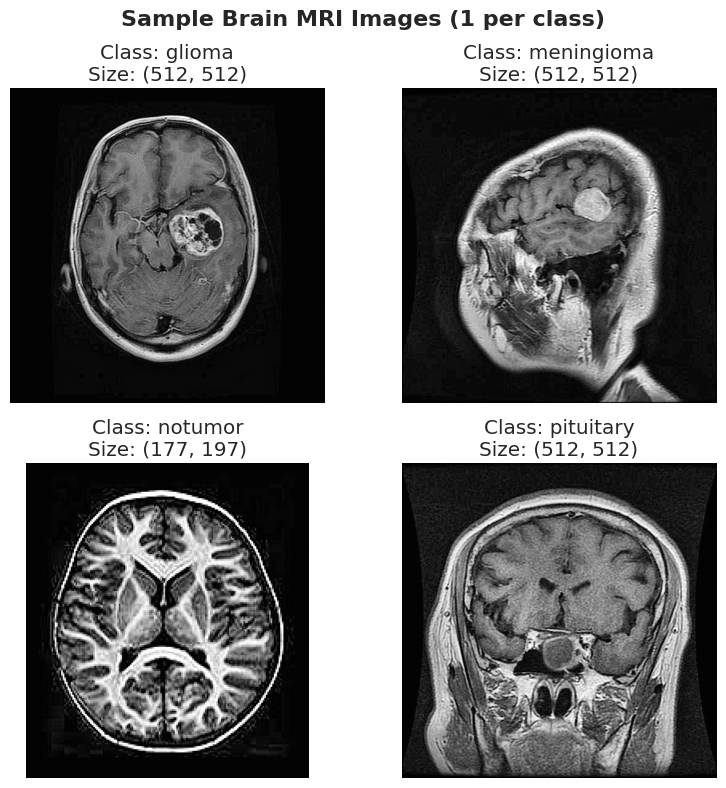

In [7]:
display_sample_images(data)

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, cohen_kappa_score, matthews_corrcoef,
                             log_loss, balanced_accuracy_score, jaccard_score,
                             hamming_loss, zero_one_loss)
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                    Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical

In [9]:
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
# data_path = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training"

data_path = os.path.join(path, 'DATASET/classification/Training')

images = []
labels = []
img_arrays = []

for subfolder in os.listdir(data_path):
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)

        img = Image.open(image_path).convert('L')
        img = img.resize((128, 128))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=-1)

        images.append(image_path)
        labels.append(subfolder)
        img_arrays.append(img_array)

In [11]:
data = pd.DataFrame({'image_path': images, 'label': labels})
X = np.array(img_arrays)
y = np.array(labels)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                                    stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                                  stratify=y_train, random_state=42)

y_train_cat = to_categorical(y_train, num_classes=len(le.classes_))
y_val_cat = to_categorical(y_val, num_classes=len(le.classes_))
y_test_cat = to_categorical(y_test, num_classes=len(le.classes_))

print(f"Training set: {X_train.shape}, {y_train_cat.shape}")
print(f"Validation set: {X_val.shape}, {y_val_cat.shape}")
print(f"Test set: {X_test.shape}, {y_test_cat.shape}")
print(f"Classes: {le.classes_}")

Training set: (3655, 128, 128, 1), (3655, 4)
Validation set: (914, 128, 128, 1), (914, 4)
Test set: (1143, 128, 128, 1), (1143, 4)
Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


# Data augmentation and class weights balance

In [12]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.081360946745562), 1: np.float64(1.0662193698949824), 2: np.float64(0.8949559255631734), 3: np.float64(0.9804184549356223)}


# Model CNN Architecture

In [13]:
model = Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(128, 128, 1)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
Dropout(0.2)

model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
Dropout(0.5)


model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dropout(0.3))

model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))


model.add(Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))



model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,052 (6.02 MB)

 Trainable params: 1,577,092 (6.02 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
# compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# callbacks

In [15]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

In [16]:
history_cnn = model.fit( # cambié el nombre
    datagen.flow(X_train, y_train_cat, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/30


114/114 - 156s - 1s/step - accuracy: 0.6119 - loss: 1.0563 - val_accuracy: 0.3151 - val_loss: 2.5978 - learning_rate: 0.0010
Epoch 2/30


114/114 - 12s - 103ms/step - accuracy: 0.5938 - loss: 1.0210 - val_accuracy: 0.3228 - val_loss: 2.5736 - learning_rate: 0.0010
Epoch 3/30


114/114 - 180s - 2s/step - accuracy: 0.7174 - loss: 0.7922 - val_accuracy: 0.5744 - val_loss: 2.1431 - learning_rate: 0.0010
Epoch 4/30
114/114 - 9s - 83ms/step - accuracy: 0.7500 - loss: 0.6689 - val_accuracy: 0.4880 - val_loss: 2.1771 - learning_rate: 0.0010
Epoch 5/30
114/114 - 190s - 2s/step - accuracy: 0.7428 - loss: 0.7286 - val_accuracy: 0.2790 - val_loss: 6.1159 - learning_rate: 0.0010
Epoch 6/30
114/114 - 11s - 99ms/step - accuracy: 0.6562 - loss: 0.6393 - val_accuracy: 0.2790 - val_loss: 5.9541 - learning_rate: 0.0010
Epoch 7/30
114/114 - 195s - 2s/step - accuracy: 0.7745 - loss: 0.6411 - val_accuracy: 0.5230 - val_loss: 1.9482 - learning_rate: 0.0010
Epoch 8/30
114/114 - 11s - 100ms/step - accuracy: 0.8125 - loss: 0.4973 - val_accuracy: 0.5711 - val_loss: 1.6755 - learning_rate: 0.0010
Epoch 9/30


114/114 - 142s - 1s/step - accuracy: 0.7861 - loss: 0.6434 - val_accuracy: 0.7123 - val_loss: 0.9262 - learning_rate: 0.0010
Epoch 10/30


114/114 - 11s - 100ms/step - accuracy: 0.6875 - loss: 0.7155 - val_accuracy: 0.7243 - val_loss: 0.8656 - learning_rate: 0.0010
Epoch 11/30


114/114 - 142s - 1s/step - accuracy: 0.7913 - loss: 0.5925 - val_accuracy: 0.8118 - val_loss: 0.5836 - learning_rate: 0.0010
Epoch 12/30


114/114 - 12s - 108ms/step - accuracy: 0.7812 - loss: 0.4404 - val_accuracy: 0.8315 - val_loss: 0.5511 - learning_rate: 0.0010
Epoch 13/30
114/114 - 190s - 2s/step - accuracy: 0.8118 - loss: 0.5672 - val_accuracy: 0.7451 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 14/30
114/114 - 10s - 85ms/step - accuracy: 0.8438 - loss: 0.4859 - val_accuracy: 0.7702 - val_loss: 0.6218 - learning_rate: 0.0010
Epoch 15/30
114/114 - 193s - 2s/step - accuracy: 0.8115 - loss: 0.5721 - val_accuracy: 0.6335 - val_loss: 1.2994 - learning_rate: 0.0010
Epoch 16/30
114/114 - 9s - 81ms/step - accuracy: 0.8438 - loss: 0.4645 - val_accuracy: 0.6160 - val_loss: 1.4337 - learning_rate: 0.0010
Epoch 17/30
114/114 - 139s - 1s/step - accuracy: 0.8283 - loss: 0.5377 - val_accuracy: 0.5591 - val_loss: 1.4277 - learning_rate: 0.0010
Epoch 18/30
114/114 - 10s - 83ms/step - accuracy: 0.7500 - loss: 0.6613 - val_accuracy: 0.5602 - val_loss: 1.4185 - learning_rate: 2.0000e-04
Epoch 19/30


114/114 - 195s - 2s/step - accuracy: 0.8496 - loss: 0.4673 - val_accuracy: 0.8512 - val_loss: 0.4544 - learning_rate: 2.0000e-04
Epoch 20/30


114/114 - 12s - 101ms/step - accuracy: 0.8438 - loss: 0.3698 - val_accuracy: 0.8534 - val_loss: 0.4548 - learning_rate: 2.0000e-04
Epoch 21/30
114/114 - 142s - 1s/step - accuracy: 0.8689 - loss: 0.4321 - val_accuracy: 0.8042 - val_loss: 0.5656 - learning_rate: 2.0000e-04
Epoch 22/30
114/114 - 8s - 72ms/step - accuracy: 0.8750 - loss: 0.3976 - val_accuracy: 0.8140 - val_loss: 0.5538 - learning_rate: 2.0000e-04
Epoch 23/30
114/114 - 191s - 2s/step - accuracy: 0.8736 - loss: 0.4087 - val_accuracy: 0.8425 - val_loss: 0.4951 - learning_rate: 2.0000e-04
Epoch 24/30
114/114 - 11s - 99ms/step - accuracy: 0.7500 - loss: 0.4604 - val_accuracy: 0.8446 - val_loss: 0.4833 - learning_rate: 2.0000e-04
Epoch 25/30
114/114 - 190s - 2s/step - accuracy: 0.8830 - loss: 0.3994 - val_accuracy: 0.8184 - val_loss: 0.5353 - learning_rate: 4.0000e-05
Epoch 26/30
114/114 - 11s - 99ms/step - accuracy: 0.8438 - loss: 0.5891 - val_accuracy: 0.8184 - val_loss: 0.5334 - learning_rate: 4.0000e-05
Epoch 27/30
114/114 -

In [17]:
model.load_weights('best_model.h5')

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8434
Test Loss: 0.5084


In [19]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

y_test_true = y_test

36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 287ms/step


In [20]:
metrics = {}

metrics['Accuracy'] = accuracy_score(y_test_true, y_pred)
metrics['Precision (Macro)'] = precision_score(y_test_true, y_pred, average='macro')
metrics['Recall (Macro)'] = recall_score(y_test_true, y_pred, average='macro')
metrics['F1-Score (Macro)'] = f1_score(y_test_true, y_pred, average='macro')
metrics['Precision (Micro)'] = precision_score(y_test_true, y_pred, average='micro')
metrics['Recall (Micro)'] = recall_score(y_test_true, y_pred, average='micro')
metrics['F1-Score (Micro)'] = f1_score(y_test_true, y_pred, average='micro')
metrics['Precision (Weighted)'] = precision_score(y_test_true, y_pred, average='weighted')
metrics['Recall (Weighted)'] = recall_score(y_test_true, y_pred, average='weighted')
metrics['F1-Score (Weighted)'] = f1_score(y_test_true, y_pred, average='weighted')

metrics['Cohen Kappa Score'] = cohen_kappa_score(y_test_true, y_pred)
metrics['Matthews Correlation Coefficient'] = matthews_corrcoef(y_test_true, y_pred)
metrics['Balanced Accuracy'] = balanced_accuracy_score(y_test_true, y_pred)
metrics['Jaccard Score (Macro)'] = jaccard_score(y_test_true, y_pred, average='macro')
metrics['Hamming Loss'] = hamming_loss(y_test_true, y_pred)
metrics['Zero-One Loss'] = zero_one_loss(y_test_true, y_pred)

In [21]:
cnn_metrics = metrics.copy() # Para guardar las métricas del cnn separadas

In [22]:
num_classes=4

y_test_bin = to_categorical(y_test_true, num_classes=num_classes)

roc_auc_scores = []
pr_auc_scores = []


for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc_scores.append(average_precision_score(y_test_bin[:, i], y_pred_proba[:, i]))

metrics['ROC AUC (Macro)'] = np.mean(roc_auc_scores)
metrics['PR AUC (Macro)'] = np.mean(pr_auc_scores)

metrics['Log Loss'] = log_loss(y_test_bin, y_pred_proba)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nEvaluation Metrics:")
print(metrics_df.round(4))


Evaluation Metrics:
                              Metric   Value
0                           Accuracy  0.8434
1                  Precision (Macro)  0.8546
2                     Recall (Macro)  0.8342
3                   F1-Score (Macro)  0.8347
4                  Precision (Micro)  0.8434
5                     Recall (Micro)  0.8434
6                   F1-Score (Micro)  0.8434
7               Precision (Weighted)  0.8532
8                  Recall (Weighted)  0.8434
9                F1-Score (Weighted)  0.8388
10                 Cohen Kappa Score  0.7899
11  Matthews Correlation Coefficient  0.7959
12                 Balanced Accuracy  0.8342
13             Jaccard Score (Macro)  0.7239
14                      Hamming Loss  0.1566
15                     Zero-One Loss  0.1566
16                   ROC AUC (Macro)  0.9676
17                    PR AUC (Macro)  0.9106
18                          Log Loss  0.4392


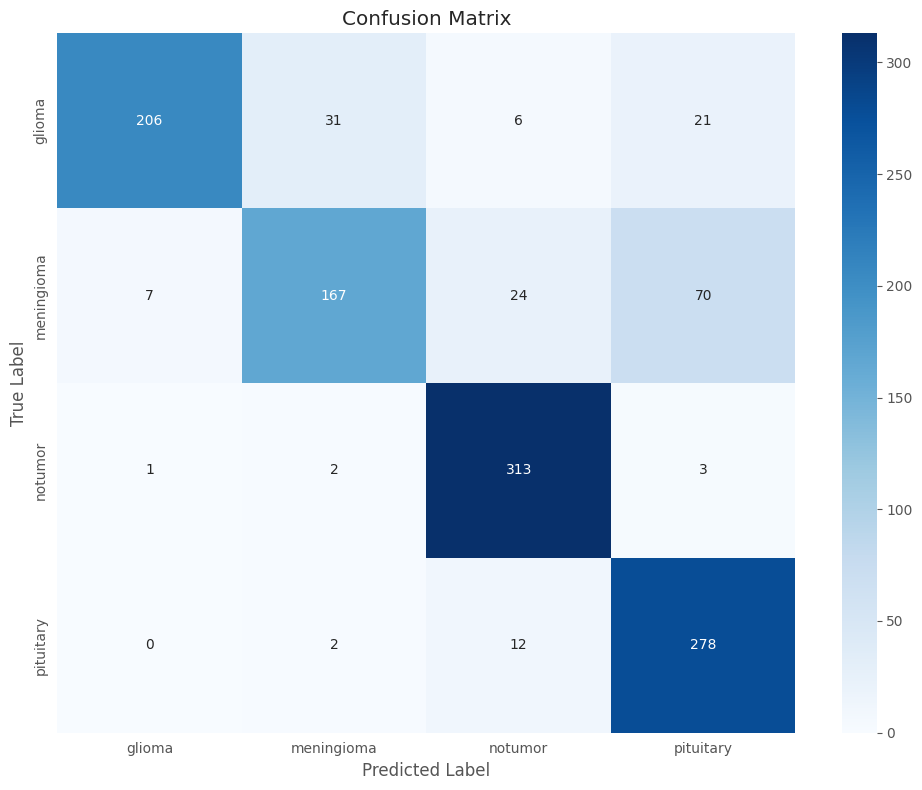

In [23]:
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [24]:
print("\nClassification Report:")
print(classification_report(y_test_true, y_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.78      0.86       264
  meningioma       0.83      0.62      0.71       268
     notumor       0.88      0.98      0.93       319
   pituitary       0.75      0.95      0.84       292

    accuracy                           0.84      1143
   macro avg       0.85      0.83      0.83      1143
weighted avg       0.85      0.84      0.84      1143



# Model MLP Architecture

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# We assume your MRI images have been resized to 128x128 pixels and are grayscale (1 channel).
# Change this if your images are RGB (128, 128, 3) or a different size.
INPUT_SHAPE = (128, 128, 1)

# Building the MLP Classification Model directly using Sequential
model = Sequential([
    # 1. Input layer: Flatten the 2D image array into a 1D vector
    Flatten(input_shape=INPUT_SHAPE),

    # 2. First Hidden Block
    # Using L2 regularization to keep the neural weights from growing too large
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5), # Dropping 50% of connections to prevent memorization

    # 3. Second Hidden Block
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    # 4. Third Hidden Block
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # 5. Output Layer: Exactly 4 neurons for your 4 brain tumor classes
    # Softmax ensures the outputs are probabilities that sum to 1
    Dense(4, activation='softmax')
])

# View the architecture and the parameter count
model.summary()

# Compiling the model for multi-class classification
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slightly lower learning rate for MLPs
    loss='categorical_crossentropy', # Use 'sparse_categorical_crossentropy' if your labels are integers (0,1,2,3)
    metrics=['accuracy']
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,442,564 (66.54 MB)

 Trainable params: 17,438,980 (66.52 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [39]:
history_mlp = model.fit( # cambié el nombre
    datagen.flow(X_train, y_train_cat, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/30
114/114 - 60s - 525ms/step - accuracy: 0.3977 - loss: 4.5270 - val_accuracy: 0.2757 - val_loss: 8.2954 - learning_rate: 5.0000e-04
Epoch 2/30
114/114 - 4s - 31ms/step - accuracy: 0.3750 - loss: 4.4487 - val_accuracy: 0.2757 - val_loss: 8.1992 - learning_rate: 5.0000e-04
Epoch 3/30
114/114 - 77s - 677ms/step - accuracy: 0.4659 - loss: 3.9039 - val_accuracy: 0.4190 - val_loss: 3.8330 - learning_rate: 5.0000e-04
Epoch 4/30
114/114 - 3s - 26ms/step - accuracy: 0.3125 - loss: 4.0546 - val_accuracy: 0.4212 - val_loss: 3.8136 - learning_rate: 5.0000e-04
Epoch 5/30
114/114 - 78s - 685ms/step - accuracy: 0.4792 - loss: 3.5871 - val_accuracy: 0.6007 - val_loss: 3.1060 - learning_rate: 5.0000e-04
Epoch 6/30
114/114 - 6s - 49ms/step - accuracy: 0.5938 - loss: 3.1108 - val_accuracy: 0.6007 - val_loss: 3.1032 - learning_rate: 1.0000e-04
Epoch 7/30
114/114 - 77s - 672ms/step - accuracy: 0.4894 - loss: 3.3559 - val_accuracy: 0.6302 - val_loss: 2.9979 - learning_rate: 1.0000e-04
Epoch 8/30
1

In [40]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.2756
Test Loss: 8.3261


In [41]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

y_test_true = y_test

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [42]:
metrics = {}

metrics['Accuracy'] = accuracy_score(y_test_true, y_pred)
metrics['Precision (Macro)'] = precision_score(y_test_true, y_pred, average='macro')
metrics['Recall (Macro)'] = recall_score(y_test_true, y_pred, average='macro')
metrics['F1-Score (Macro)'] = f1_score(y_test_true, y_pred, average='macro')
metrics['Precision (Micro)'] = precision_score(y_test_true, y_pred, average='micro')
metrics['Recall (Micro)'] = recall_score(y_test_true, y_pred, average='micro')
metrics['F1-Score (Micro)'] = f1_score(y_test_true, y_pred, average='micro')
metrics['Precision (Weighted)'] = precision_score(y_test_true, y_pred, average='weighted')
metrics['Recall (Weighted)'] = recall_score(y_test_true, y_pred, average='weighted')
metrics['F1-Score (Weighted)'] = f1_score(y_test_true, y_pred, average='weighted')

metrics['Cohen Kappa Score'] = cohen_kappa_score(y_test_true, y_pred)
metrics['Matthews Correlation Coefficient'] = matthews_corrcoef(y_test_true, y_pred)
metrics['Balanced Accuracy'] = balanced_accuracy_score(y_test_true, y_pred)
metrics['Jaccard Score (Macro)'] = jaccard_score(y_test_true, y_pred, average='macro')
metrics['Hamming Loss'] = hamming_loss(y_test_true, y_pred)
metrics['Zero-One Loss'] = zero_one_loss(y_test_true, y_pred)

In [43]:
mlp_metrics = metrics.copy()

In [44]:
num_classes=4

y_test_bin = to_categorical(y_test_true, num_classes=num_classes)

roc_auc_scores = []
pr_auc_scores = []


for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc_scores.append(average_precision_score(y_test_bin[:, i], y_pred_proba[:, i]))

metrics['ROC AUC (Macro)'] = np.mean(roc_auc_scores)
metrics['PR AUC (Macro)'] = np.mean(pr_auc_scores)

metrics['Log Loss'] = log_loss(y_test_bin, y_pred_proba)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print("\nEvaluation Metrics:")
print(metrics_df.round(4))


Evaluation Metrics:
                              Metric   Value
0                           Accuracy  0.2756
1                  Precision (Macro)  0.0708
2                     Recall (Macro)  0.2469
3                   F1-Score (Macro)  0.1100
4                  Precision (Micro)  0.2756
5                     Recall (Micro)  0.2756
6                   F1-Score (Micro)  0.2756
7               Precision (Weighted)  0.0790
8                  Recall (Weighted)  0.2756
9                F1-Score (Weighted)  0.1228
10                 Cohen Kappa Score -0.0032
11  Matthews Correlation Coefficient -0.0120
12                 Balanced Accuracy  0.2469
13             Jaccard Score (Macro)  0.0705
14                      Hamming Loss  0.7244
15                     Zero-One Loss  0.7244
16                   ROC AUC (Macro)  0.6973
17                    PR AUC (Macro)  0.4511
18                          Log Loss  5.6247


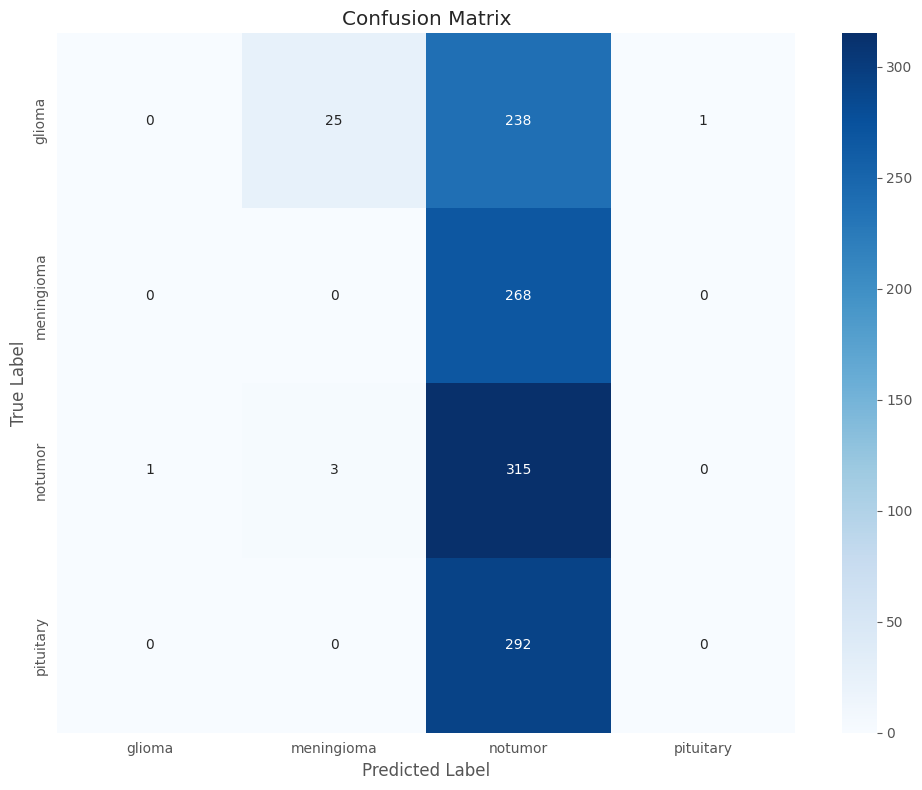

In [45]:
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Learning curves

## CNN

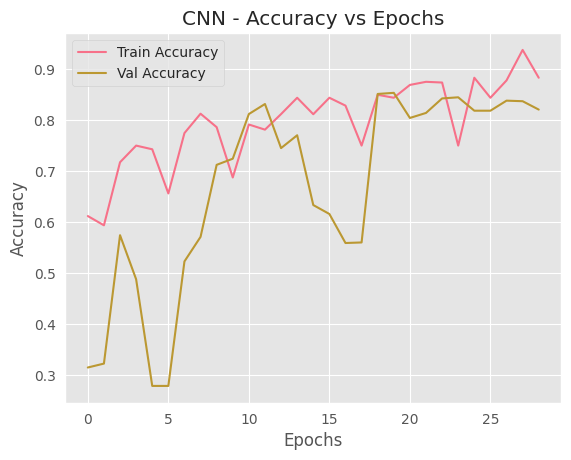

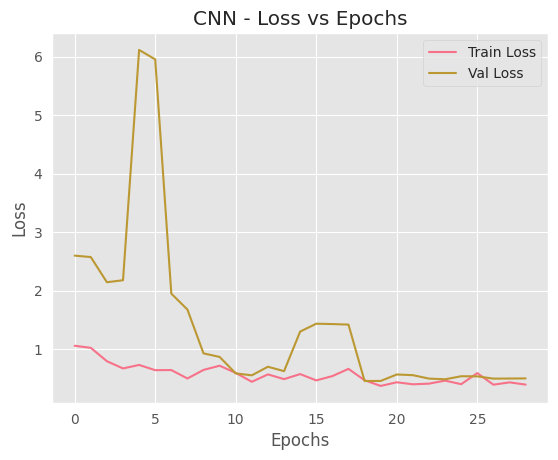

In [46]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN - Accuracy vs Epochs')

plt.show()

# Loss
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN - Loss vs Epochs')

plt.show()

## MLP

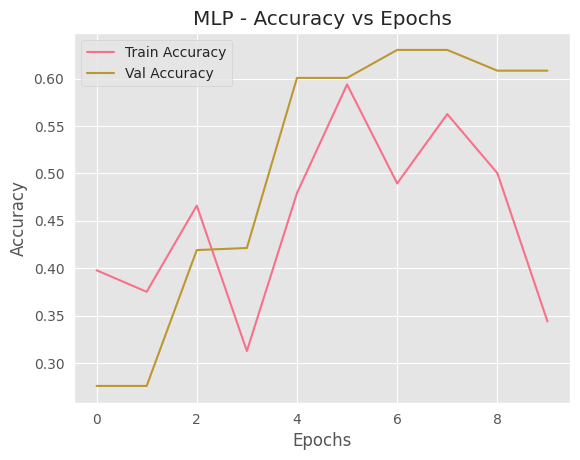

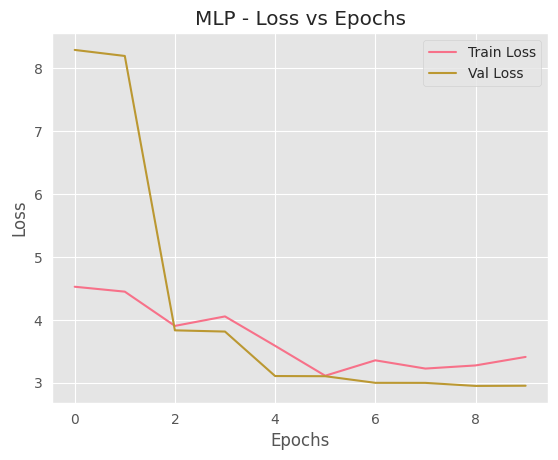

In [47]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP - Accuracy vs Epochs')

plt.show()

# Loss
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP - Loss vs Epochs')

plt.show()

## CNN vs MLP

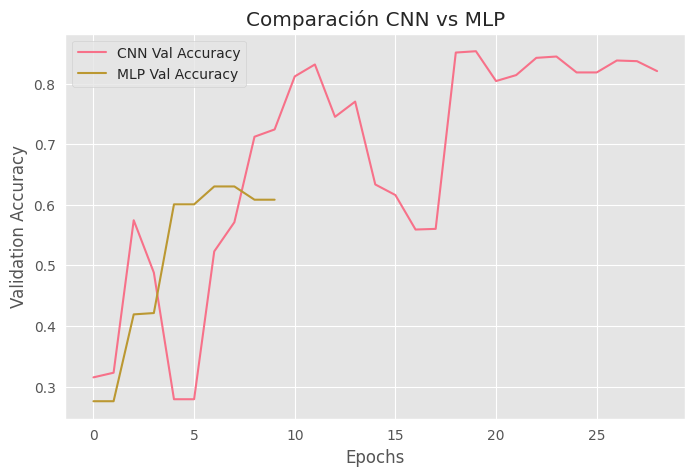

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')

plt.title('Comparación CNN vs MLP')
plt.legend()

plt.show()

In [49]:
import pandas as pd

comparison_df = pd.DataFrame({
    'CNN': cnn_metrics,
    'MLP': mlp_metrics
})

print(comparison_df)

                                       CNN       MLP
Accuracy                          0.843395  0.275591
Precision (Macro)                 0.854588  0.070755
Recall (Macro)                    0.834171  0.246865
F1-Score (Macro)                  0.834674  0.109986
Precision (Micro)                 0.843395  0.275591
Recall (Micro)                    0.843395  0.275591
F1-Score (Micro)                  0.843395  0.275591
Precision (Weighted)              0.853167  0.078988
Recall (Weighted)                 0.843395  0.275591
F1-Score (Weighted)               0.838834  0.122784
Cohen Kappa Score                 0.789930 -0.003246
Matthews Correlation Coefficient  0.795930 -0.011972
Balanced Accuracy                 0.834171  0.246865
Jaccard Score (Macro)             0.723938  0.070501
Hamming Loss                      0.156605  0.724409
Zero-One Loss                     0.156605  0.724409


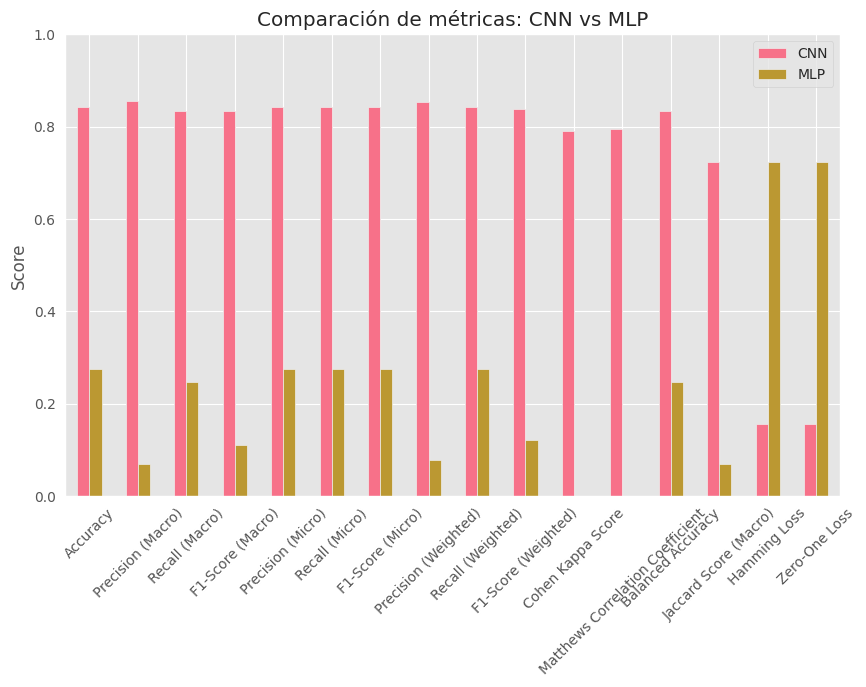

In [50]:
comparison_df.plot(kind='bar', figsize=(10,6))

plt.title('Comparación de métricas: CNN vs MLP')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=45)

plt.show()